### Instructions: 
 - define model parameters, 
 - fit model to data to calibrate velocity scale, 
 - fit data and model to lorentzian, 
 - verify the are consistent

In [108]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
from mossbauer_analysis.fit_functions import linear, poly2,poly5, single_peak_lorentzian_poly1, single_peak_lorentzian_poly2, six_peak_lorentzian_poly1,six_peak_lorentzian_poly2, six_peak_lorentzian_poly5

import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lorentzian(p,x):
    x0, Gamma, A, eta_nr = p
    return eta_nr-A*(Gamma/2)**2 / ((x-x0)**2 + (Gamma/2)**2)


In [3]:
v = np.linspace(-3,3,1000)    


#SOURCE
sourceFe = CobaltFe ()
sourceFe.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
sourceFe.Gamma_ev = 6.75e-9
sourceFe.update_params()

#ABSORBER Alpha Fe
absorberAlpha = alphaFe()
absorberAlpha.thickness_m = 25e-6
absorberAlpha.abundance = 0.0212
absorberAlpha.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn


absorberAlpha.update_params()


#ABSORBER A1
absorberA1 = alphaFe()
absorberA1.thickness_m = 260e-9
absorberA1.abundance = 0.96
absorberA1.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA1.update_params()
#CALCULATIONS
moss_Alpha = Mossbauer(sourceFe, absorberAlpha)
moss_A1 = Mossbauer(sourceFe, absorberA1)

t_Alpha = moss_Alpha.total_transmission_rate(v)
t_A1 = moss_A1.total_transmission_rate(v)



#ABSORBER A2
absorberA2 = alphaFe()
absorberA2.thickness_m = 200e-9
absorberA2.abundance = 0.96
absorberA2.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberA2.update_params()
#CALCULATIONS
moss_Alpha = Mossbauer(sourceFe, absorberAlpha)
moss_A2 = Mossbauer(sourceFe, absorberA2)   

t_Alpha = moss_Alpha.total_transmission_rate(v)
t_A2 = moss_A2.total_transmission_rate(v)




In [4]:
directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
["A00135","A00137","A00138","A00141","A00142"]

data_alphaFe = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_A1 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)
data_A2 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)

## AlphaFe

Fit parameters: A=1.105, s=1.372, v0=-0.004, B=0.688
Lorentzian fit to measurement: x0:-0.011, Gamma:0.279, A:0.105, eta_nr:1.001
Lorentzian fit to model:       x0:-0.000, Gamma:0.279, A:0.107, eta_nr:1.001
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


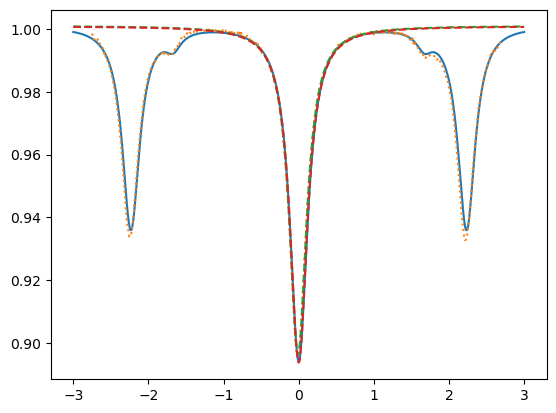

In [5]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_Alpha
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)

def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


# Measured Data
x_meas = data_alphaFe.velocity_list
y_meas = data_alphaFe.data_folded/max(data_alphaFe.data_folded)



#Fit the model to the data
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=[1,1.3,0,0.7], fullout=False)
A, s, v0, B = p
print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (-1.3)))
idx1 = np.argmin(np.abs(x_calibrated - 1.3))
x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[0,0.2,0.5,0], fullout=False)
print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (-1.3)))
idx1 = np.argmin(np.abs(x_model - 1.3))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")

## A1

Fit parameters: A=0.328, s=1.381, v0=-0.003, B=0.675
Lorentzian fit to measurement: x0:-0.007, Gamma:0.255, A:0.066, eta_nr:0.998
Lorentzian fit to model:       x0:0.000, Gamma:0.255, A:0.068, eta_nr:0.998
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


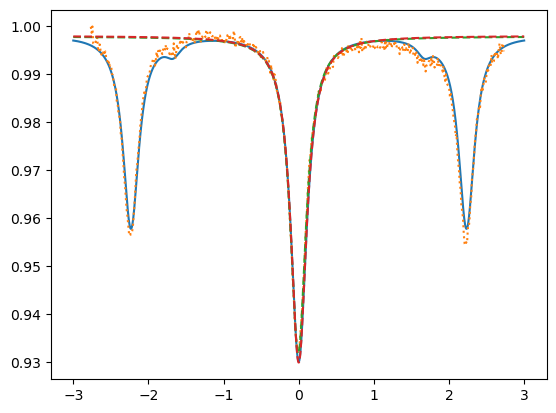

In [6]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_A1
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)

def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


# Measured Data
x_meas = data_A1.velocity_list
y_meas = data_A1.data_folded/max(data_A1.data_folded)


#Fit the model to the data
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=[1,1.3,0,0.7], fullout=False)
A, s, v0, B = p
print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (-1.3)))
idx1 = np.argmin(np.abs(x_calibrated - 1.3))
x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[0,0.2,0.5,0], fullout=False)
print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (-1.3)))
idx1 = np.argmin(np.abs(x_model - 1.3))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")

## A2

Fit parameters: A=0.304, s=1.385, v0=-0.004, B=0.696
Lorentzian fit to measurement: x0:-0.010, Gamma:0.250, A:0.050, eta_nr:0.997
Lorentzian fit to model:       x0:-0.000, Gamma:0.250, A:0.052, eta_nr:0.997
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


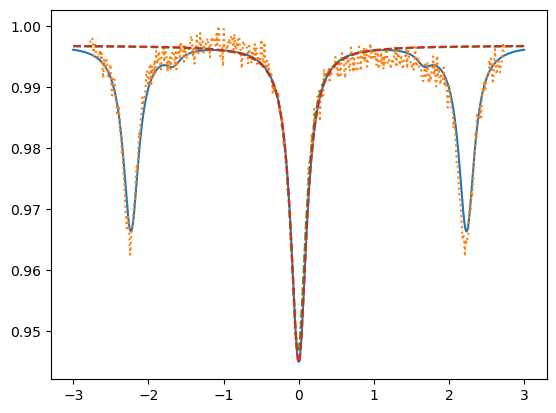

In [7]:
from scipy.interpolate import interp1d


# Model Data and interpolation function
x_model = v
y_model = t_A2
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)

def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


# Measured Data
x_meas = data_A2.velocity_list
y_meas = data_A2.data_folded/max(data_A2.data_folded)


#Fit the model to the data
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=[1,1.3,0,0.7], fullout=False)
A, s, v0, B = p
print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (-1.3)))
idx1 = np.argmin(np.abs(x_calibrated - 1.3))
x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[0,0.2,0.5,0], fullout=False)
print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (-1.3)))
idx1 = np.argmin(np.abs(x_model - 1.3))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")

In [98]:
v = np.linspace(-8,8,1000)    


#SOURCE
sourceRh = CobaltRhodium ()
sourceRh.Eres = [-0.11] #from pipcorn
sourceRh.Gamma_ev = 6.75e-9
sourceRh.update_params()


#ABSORBER DEP10
absorberDep10 = alphaFe()
absorberDep10.thickness_m = 650e-9
absorberDep10.abundance = 0.96
absorberDep10.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberDep10.update_params()
#CALCULATIONS
moss_Dep10 = Mossbauer(sourceRh, absorberDep10)
moss_A1 = Mossbauer(sourceRh, absorberA1)

t_Dep10 = moss_Dep10.total_transmission_rate(v)





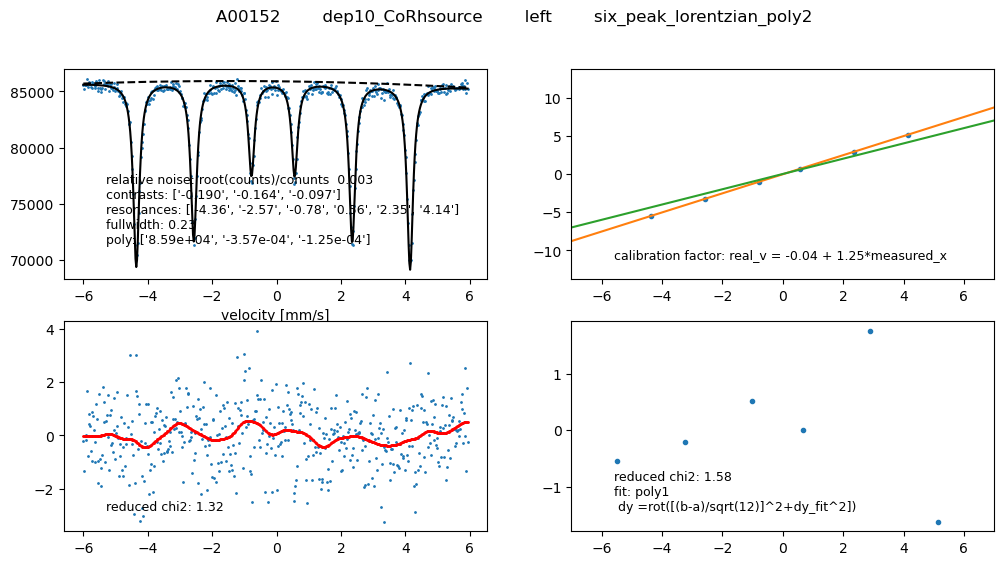

In [109]:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e5, 1e2, 1e1],  
            }

params = {  'directory': 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/',
            'id': 'A00152',
            'offset': -3,
            'side': 'left',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)

Fit parameters: A=0.430, s=1.250, v0=-0.040, B=0.580
Lorentzian fit to measurement: x0:6.149, Gamma:-0.794, A:-0.069, eta_nr:0.938
Lorentzian fit to model:       x0:6.251, Gamma:-0.462, A:-0.054, eta_nr:0.946
Note:the linewidth is not fitted!
Minimum theory linewidth (no thickness broadening, just source+absorber): 0.141+0.095 = 0.235 mm/s


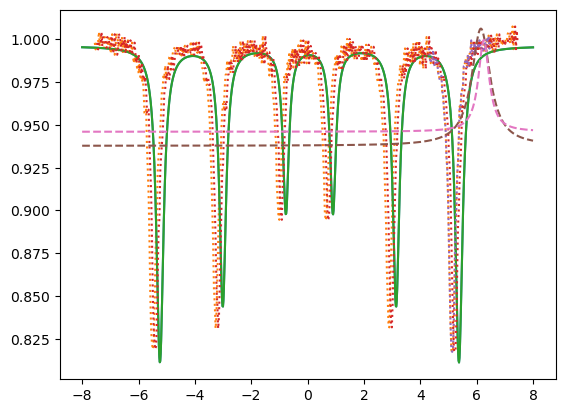

In [138]:

x_model = v
y_model = t_Dep10
model_interp = interp1d( x_model, y_model, kind="cubic",bounds_error=False,fill_value=0.0)


# Measured Data
def fit_interpolation(p,x):
    A, s, x0, B = p
    return A * model_interp(s * (x - x0)) + B


data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
x_meas = data_dep10.velocity_list
y_meas = params['y']/poly2(params['poly'], params['x'])





#Fit the model to the data
p0 = [0.43, 1.25, -0.04, 0.58]
p, dp = u.fit(fit_interpolation, x_meas, y_meas, p0=p0, fullout=False)
A, s, v0, B = p
A, s, v0, B = p0


print(f"Fit parameters: A={A:.3f}, s={s:.3f}, v0={v0:.3f}, B={B:.3f}")
plt.plot(x_model, A*y_model+B, label='Alpha Fe Absorber')
plt.plot((x_meas+v0)*s, y_meas, label='Alpha Fe Data', linestyle='dotted')


plt.plot(x_model, A*y_model+B, label='dep10')
plt.plot(s*(x_meas)-v0, y_meas, label='Alpha Fe Data', linestyle='dotted')


#now fit a lorentzian to see actual linewidth
#select limited vrange
x_calibrated = (x_meas+v0)*s
idx0 = np.argmin(np.abs(x_calibrated - (4.3)))
idx1 = np.argmin(np.abs(x_calibrated - 6.5))

x_meas_fit = x_calibrated[idx0:idx1]
y_meas_fit = y_meas[idx0:idx1]
p, dp = u.fit(lorentzian, x_meas_fit, y_meas_fit, p0=[5.5,0.2,-0.5,0], fullout=False)

print(f"Lorentzian fit to measurement: x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")

plt.plot(x_meas_fit, y_meas_fit, label='Data Fit Range', linestyle='dotted')
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit', linestyle='--')

#also fit the model linewidth
idx0 = np.argmin(np.abs(x_model - (4.3)))
idx1 = np.argmin(np.abs(x_model - 6.5))
x_mod_fit = x_model[idx0:idx1]
y_mod_fit = y_model[idx0:idx1]
p, dp = u.fit(lorentzian, x_mod_fit, A*y_mod_fit+B, p0=p, fullout=False)
print(f"Lorentzian fit to model:       x0:{p[0]:.3f}, Gamma:{p[1]:.3f}, A:{p[2]:.3f}, eta_nr:{p[3]:.3f}")
print("Note:the linewidth is not fitted!")
plt.plot(x_model, lorentzian(p, x_model), label='Lorentzian Fit Model', linestyle='--')

print(f"Minimum theory linewidth (no thickness broadening, just source+absorber): {sourceFe.Gamma:.3f}+{absorberAlpha.Gamma:.3f} = { sourceFe.Gamma + absorberAlpha.Gamma :.3f} mm/s")


In [129]:
poly2(params['poly'], params['x'])

array([85687.70728019, 85690.01445653, 85692.30976038, 85694.59319173,
       85696.86475059, 85699.12443695, 85701.37225083, 85703.60819221,
       85705.83226109, 85708.04445749, 85710.24478139, 85712.4332328 ,
       85714.60981172, 85716.77451814, 85718.92735207, 85721.06831351,
       85723.19740245, 85725.31461891, 85727.41996287, 85729.51343433,
       85731.59503331, 85733.66475979, 85735.72261378, 85737.76859527,
       85739.80270428, 85741.82494079, 85743.8353048 , 85745.83379633,
       85747.82041536, 85749.7951619 , 85751.75803594, 85753.7090375 ,
       85755.64816656, 85757.57542313, 85759.4908072 , 85761.39431878,
       85763.28595787, 85765.16572447, 85767.03361857, 85768.88964018,
       85770.7337893 , 85772.56606593, 85774.38647006, 85776.1950017 ,
       85777.99166085, 85779.7764475 , 85781.54936166, 85783.31040333,
       85785.05957251, 85786.79686919, 85788.52229338, 85790.23584508,
       85791.93752428, 85793.62733099, 85795.30526521, 85796.97132694,
      

In [128]:
params

{'directory': 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/',
 'id': 'A00152',
 'offset': -3,
 'side': 'left',
 'npeaks': 6,
 'fitfunction': <function mossbauer_analysis.fit_functions.six_peak_lorentzian_poly2(p, x)>,
 'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.9, 5.13],
 'description': 'dep10_CoRhsource',
 'reduced_chi2': 1.3218266774486696,
 'total_rate': 6664.910954616588,
 'total_counts': 85177562,
 'total_time': 12780.0,
 'total_rate_fit': 6882.048232071795,
 'total_rate_fit_error': 0.7338265643935811,
 'resonances': [-4.355091731254467,
  -2.5704785715439216,
  -0.7792285437427178,
  0.559643837579736,
  2.3481064660352446,
  4.143472735525878],
 'contrasts': [-0.19043579835272428,
  -0.16441629550456183,
  -0.09690667454789936],
 'fullwidth': 0.22698654981883348,
 'poly': [85891.18789636478, -0.00035711663652842945, -0.00012532641539287446],
 'velocity_calibration': array([-0.03895862,  1.24889611]),
 'y': array([85516, 85191, 85577, 8552